# 3. Training, learning, and validation curves

Use the three curves as an iterative workflow:

1. establish a model and initial settings using training and validation data;
2. inspect optimization stability and budget with a training curve;
3. inspect data effects with a learning curve;
4. inspect one complexity or hyperparameter choice with a validation curve;
5. refine and repeat, leaving the test set untouched until final assessment.

Curve shapes are clues. Insufficient optimization can resemble underfitting, and
stochastic variation can blur differences between settings.

In [1]:
import importlib.metadata
import platform
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
started = perf_counter()
print("Python", platform.python_version(), "|", platform.system(), platform.machine())
print(
    "Versions:",
    {
        package: importlib.metadata.version(package)
        for package in [
            "pyperch",
            "torch",
            "numpy",
            "matplotlib",
            "scikit-learn",
            "optuna",
        ]
    },
)

Python 3.12.13 | Darwin arm64
Versions: {'pyperch': '0.3.2', 'torch': '2.12.0', 'numpy': '2.2.6', 'matplotlib': '3.10.9', 'scikit-learn': '1.7.2', 'optuna': '4.8.0'}


## Fixed data and fitting protocol

Split bundled digits once into about 60% training pool, 20% validation, and 20%
reserved test data. Each repeat builds class-balanced nested training subsets and
fits preprocessing only on its selected subset. Fresh 64 to hidden-width to 10 tanh
networks use Adam (`lr=0.01`) for 200 full-batch updates.

Seeds 11, 22, and 33 vary subset order and initialization. Repeats therefore show
observed run-to-run spread on one fixed split, not a confidence interval.

In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from pyperch.plotting import (
    plot_learning_curve,
    plot_training_curve,
    plot_validation_curve,
    prepare_learning_curve,
    prepare_training_curve,
    prepare_validation_curve,
)

digits = load_digits()
indices = np.arange(len(digits.target))
pool, reserved = train_test_split(
    indices,
    test_size=0.4,
    stratify=digits.target,
    random_state=42,
)
validation, test = train_test_split(
    reserved,
    test_size=0.5,
    stratify=digits.target[reserved],
    random_state=42,
)
SEEDS = [11, 22, 33]
SIZES = [60, 120, 240, 480, 960]
WIDTHS = [2, 8, 32, 128]
UPDATES = 200
CHECKPOINTS = np.arange(0, UPDATES + 1, 10)
print(
    "Split counts:",
    {
        "training pool": len(pool),
        "validation": len(validation),
        "untouched test": len(test),
    },
)


def subset_order(seed):
    rng = np.random.default_rng(seed)
    classes = [
        rng.permutation(pool[digits.target[pool] == label]) for label in range(10)
    ]
    return np.array(
        [group[index] for index in range(min(map(len, classes))) for group in classes]
    )


orders = {seed: subset_order(seed) for seed in SEEDS}
assert all(len(order) >= max(SIZES) for order in orders.values())


def fit_and_score(selected, width, seed, record=False):
    scaler = StandardScaler().fit(digits.data[selected])
    Xt = torch.tensor(scaler.transform(digits.data[selected]), dtype=torch.float32)
    Xv = torch.tensor(scaler.transform(digits.data[validation]), dtype=torch.float32)
    yt = torch.tensor(digits.target[selected], dtype=torch.long)
    yv = torch.tensor(digits.target[validation], dtype=torch.long)
    torch.manual_seed(seed)
    model = nn.Sequential(nn.Linear(64, width), nn.Tanh(), nn.Linear(width, 10))
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.CrossEntropyLoss()
    history = {"Train": [], "Validation": []}
    for update in range(UPDATES + 1):
        if update:
            optimizer.zero_grad()
            loss = loss_fn(model(Xt), yt)
            loss.backward()
            optimizer.step()
        if record and update in CHECKPOINTS:
            with torch.no_grad():
                history["Train"].append(loss_fn(model(Xt), yt).item())
                history["Validation"].append(loss_fn(model(Xv), yv).item())
    with torch.no_grad():
        train_logits, valid_logits = model(Xt), model(Xv)
        metrics = {
            "train_loss": loss_fn(train_logits, yt).item(),
            "valid_loss": loss_fn(valid_logits, yv).item(),
            "train_accuracy": (train_logits.argmax(1) == yt).float().mean().item(),
            "valid_accuracy": (valid_logits.argmax(1) == yv).float().mean().item(),
        }
    return (metrics, history) if record else metrics

Split counts: {'training pool': 1078, 'validation': 359, 'untouched test': 360}


## First check the training curve

Start with one representative width-32 model trained on 480 observations. This
single run asks whether 200 updates provide a stable enough budget before interpreting
the later data-size and width sweeps. The 10-update spacing adds 42 monitoring
forwards outside the 200 gradient updates.

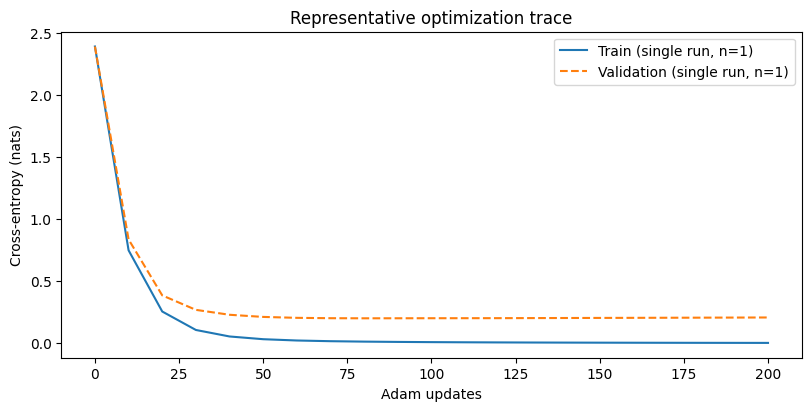

Validation loss at updates 100 / 200: 0.2022 / 0.2083


In [3]:
_, representative_history = fit_and_score(
    orders[SEEDS[0]][:480],
    width=32,
    seed=SEEDS[0],
    record=True,
)
curve = prepare_training_curve(
    CHECKPOINTS,
    representative_history,
    metric="Cross-entropy (nats)",
    x_label="Adam updates",
)
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
plot_training_curve(curve, ax=ax)
ax.set_title("Representative optimization trace")
plt.show()
print(
    "Validation loss at updates 100 / 200:",
    f"{representative_history['Validation'][10]:.4f} / "
    f"{representative_history['Validation'][20]:.4f}",
)

Training loss is near zero by 100 updates, while validation loss is 0.202 at
update 100 and 0.208 at update 200. The broad validation plateau makes 200 updates a
reasonable fixed exploratory budget, while the slight late drift warns that more
training improvement need not improve validation.

## Learning curves vary training-set size

Fit width 32 at 60, 120, 240, 480, and 960 training observations. Lines are
three-run means and ribbons are mean plus or minus sample standard deviation.
Cross-entropy measures probability quality in nats; accuracy is the fraction of
correct labels.

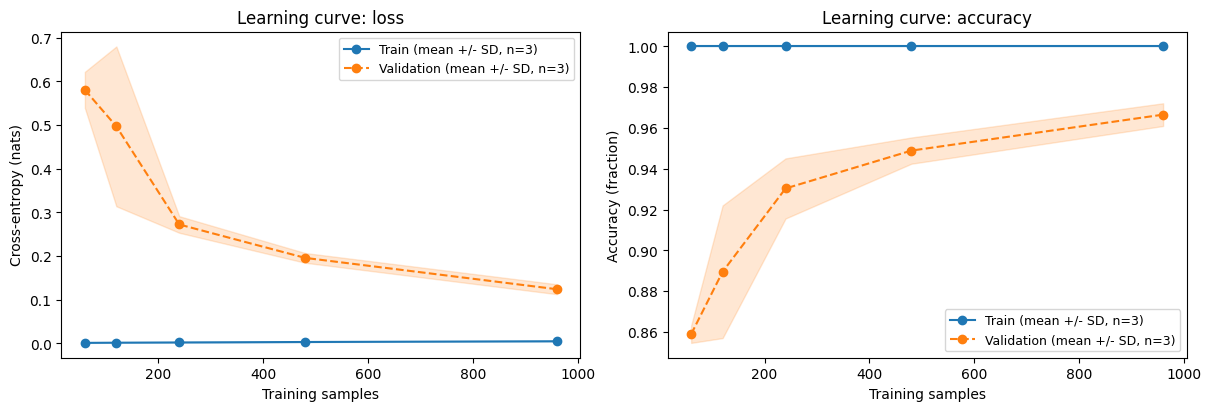

Mean validation accuracy by training size: {60: np.float64(0.859), 120: np.float64(0.89), 240: np.float64(0.93), 480: np.float64(0.949), 960: np.float64(0.967)}


In [4]:
def measured(records, key):
    return np.array([[run_result[key] for run_result in point] for point in records])


learning_results = [
    [fit_and_score(orders[seed][:size], 32, seed) for seed in SEEDS] for size in SIZES
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for ax, suffix, metric in [
    (axes[0], "loss", "Cross-entropy (nats)"),
    (axes[1], "accuracy", "Accuracy (fraction)"),
]:
    curve = prepare_learning_curve(
        SIZES,
        measured(learning_results, "train_" + suffix),
        measured(learning_results, "valid_" + suffix),
        metric=metric,
    )
    plot_learning_curve(curve, ax=ax)
    ax.set_title(f"Learning curve: {suffix}")
    ax.legend(fontsize=9)
plt.show()
mean_valid_accuracy = measured(learning_results, "valid_accuracy").mean(axis=1)
print(
    "Mean validation accuracy by training size:",
    dict(zip(SIZES, mean_valid_accuracy.round(3))),
)

Mean validation accuracy rises from 0.859 at 60 samples to 0.967 at 960, while
training accuracy stays at its ceiling. The narrowing gap is evidence that more
representative data helps in this range, not a guarantee that the trend continues.

## Validation curves vary one hyperparameter

Hold training size at 120 and vary hidden width across 2, 8, 32, and 128 units.
Within a repeat, reuse the subset and seed; width changes weight shapes, so initial
parameters cannot be identical. Selection uses validation loss only, with overlapping
seed ribbons limiting how strongly nearby widths can be distinguished.

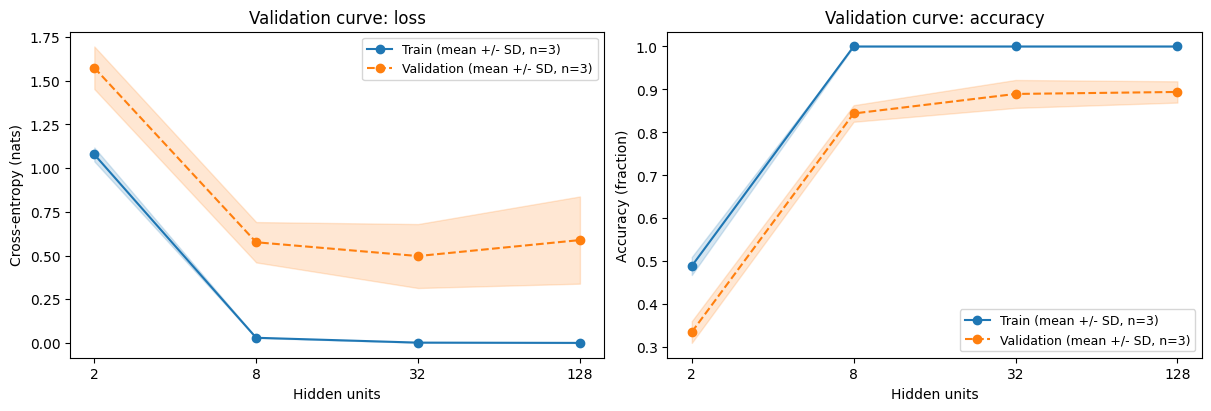

Mean validation cross-entropy: {2: np.float64(1.5742), 8: np.float64(0.5759), 32: np.float64(0.497), 128: np.float64(0.5884)}
Exploratory selected width: 32
Reserved test observations remain untouched: 360


In [5]:
validation_results = [
    [fit_and_score(orders[seed][:120], width, seed) for seed in SEEDS]
    for width in WIDTHS
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for ax, suffix, metric in [
    (axes[0], "loss", "Cross-entropy (nats)"),
    (axes[1], "accuracy", "Accuracy (fraction)"),
]:
    ax.set_xscale("log", base=2)
    curve = prepare_validation_curve(
        WIDTHS,
        measured(validation_results, "train_" + suffix),
        measured(validation_results, "valid_" + suffix),
        param_name="Hidden units",
        metric=metric,
    )
    plot_validation_curve(curve, ax=ax)
    ax.set_xticks(WIDTHS, labels=[str(width) for width in WIDTHS])
    ax.set_title(f"Validation curve: {suffix}")
    ax.legend(fontsize=9)
plt.show()
mean_losses = measured(validation_results, "valid_loss").mean(axis=1)
print("Mean validation cross-entropy:", dict(zip(WIDTHS, mean_losses.round(4))))
print("Exploratory selected width:", WIDTHS[int(mean_losses.argmin())])
print("Reserved test observations remain untouched:", len(test))

Width 2 performs poorly on both splits, a clue that capacity may be limiting.
Width 128 fits training data closely but has mean validation loss 0.588 versus 0.497
for width 32, a clue of excess complexity at this sample size. Neither is a
definitive diagnosis, and the uncertainty bands overlap. Keep width 32 provisional,
refine the workflow if needed, and evaluate the reserved test set only once.

Next: [Optuna tuning for SA and GA](04_optuna_tuning.ipynb).

In [6]:
print(f"Notebook computation and plotting: {perf_counter() - started:.2f} seconds")

Notebook computation and plotting: 1.32 seconds
